In [ ]:
#Day 5

# Feature engineering.

# feature transformation
#         -missing value imputation
#         -Encoding categorical variables.
#         -outlier Handling
#         -feature scaling
# feature construction
# feature selection 
# feature extraction


In [ ]:
# Encoding Techniques:

# -Ordinal Encoding-Ordered categories,Input features (X)
# -One-Hot Encoding-Unordered categories,Input features (X)
# -Label Encoding-Target categories,Target variable (y)


In [1]:
import pandas as pd

# Create the movie recommendation dataset
data = {
    'Age': [22, 35, 28, 45, 19, 50, 33, 27, 41, 23, 38, 31, 26, 44, 20],
    'Genre': ['Action', 'Comedy', 'Horror', 'Comedy', 'Action', 'Horror', 'Comedy', 'Action', 'Horror', 'Comedy', 'Action', 'Horror', 'Comedy', 'Action', 'Horror'],
    'Rating': ['Good', 'Excellent', 'Average', 'Good', 'Poor', 'Excellent', 'Good', 'Average', 'Excellent', 'Poor', 'Good', 'Average', 'Excellent', 'Good', 'Poor'],
    'Subscription': ['Free', 'VIP', 'Premium', 'VIP', 'Free', 'Premium', 'VIP', 'Free', 'Premium', 'Free', 'VIP', 'Premium', 'VIP', 'Premium', 'Free'],
    'Liked_Movie': ['Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'No']
}

df = pd.DataFrame(data)
print("Shape:", df.shape)
print("\nDataset:")
df
df_copy = df.copy()  # Create a copy for encoding

Shape: (15, 5)

Dataset:


In [2]:
df.head()

,Age,Genre,Rating,Subscription,Liked_Movie
0,22,Action,Good,Free,Yes
1,35,Comedy,Excellent,VIP,Yes
2,28,Horror,Average,Premium,No
3,45,Comedy,Good,VIP,Yes
4,19,Action,Poor,Free,No


In [3]:
# Check data types
print("Data Types:")
print(df.dtypes)

Data Types:
Age              int64
Genre           object
Rating          object
Subscription    object
Liked_Movie     object
dtype: object


In [4]:
print("\n--- Unique values in each categorical column ---")
for col in ['Genre', 'Rating', 'Subscription', 'Liked_Movie']:
    print(f"\n{col}: {df[col].unique()}")


--- Unique values in each categorical column ---

Genre: ['Action' 'Comedy' 'Horror']

Rating: ['Good' 'Excellent' 'Average' 'Poor']

Subscription: ['Free' 'VIP' 'Premium']

Liked_Movie: ['Yes' 'No']


In [ ]:
# Ordinal Encoding (For Ordered Categories)

# Rating:        Poor → 0,  Average → 1,  Good → 2,  Excellent → 3
# Subscription:  Free → 0,  Premium → 1,  VIP → 2

In [5]:
df[['Rating', 'Subscription']]

,Rating,Subscription
0,Good,Free
1,Excellent,VIP
2,Average,Premium
3,Good,VIP
4,Poor,Free
5,Excellent,Premium
6,Good,VIP
7,Average,Free
8,Excellent,Premium
9,Poor,Free


In [6]:
from sklearn.preprocessing import OrdinalEncoder

# Define the order for each ordinal column
# IMPORTANT: Order matters! Low to High
rating_order = ['Poor', 'Average', 'Good', 'Excellent']        # 0, 1, 2, 3
subscription_order = ['Free', 'Premium', 'VIP']                 # 0, 1, 2

# Create OrdinalEncoder with defined categories
oe = OrdinalEncoder(categories=[rating_order, subscription_order])

# Apply ordinal encoding on Rating and Subscription columns
df[['Rating', 'Subscription']] = oe.fit_transform(df[['Rating', 'Subscription']])

print("After Ordinal Encoding:")

print("\nRating mapping:      Poor=0, Average=1, Good=2, Excellent=3")
print("Subscription mapping: Free=0, Premium=1, VIP=2")
print()
df

After Ordinal Encoding:

Rating mapping:      Poor=0, Average=1, Good=2, Excellent=3
Subscription mapping: Free=0, Premium=1, VIP=2



,Age,Genre,Rating,Subscription,Liked_Movie
0,22,Action,2.0,0.0,Yes
1,35,Comedy,3.0,2.0,Yes
2,28,Horror,1.0,1.0,No
3,45,Comedy,2.0,2.0,Yes
4,19,Action,0.0,0.0,No
5,50,Horror,3.0,1.0,Yes
6,33,Comedy,2.0,2.0,Yes
7,27,Action,1.0,0.0,No
8,41,Horror,3.0,1.0,Yes
9,23,Comedy,0.0,0.0,No


In [ ]:
# Label Encoding (For Target Variable)

In [7]:
df[['Liked_Movie']]

,Liked_Movie
0,Yes
1,Yes
2,No
3,Yes
4,No
5,Yes
6,Yes
7,No
8,Yes
9,No


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Apply Label Encoding on target variable
df['Liked_Movie'] = le.fit_transform(df['Liked_Movie'])

print("Label Encoding mapping:")

for i , value in enumerate(le.classes_):
    print(f"  {i} → {value}")

print("\nDataset after Label Encoding target:")
df

Label Encoding mapping:
  0 → No
  1 → Yes

Dataset after Label Encoding target:


,Age,Genre,Rating,Subscription,Liked_Movie
0,22,Action,2.0,0.0,1
1,35,Comedy,3.0,2.0,1
2,28,Horror,1.0,1.0,0
3,45,Comedy,2.0,2.0,1
4,19,Action,0.0,0.0,0
5,50,Horror,3.0,1.0,1
6,33,Comedy,2.0,2.0,1
7,27,Action,1.0,0.0,0
8,41,Horror,3.0,1.0,1
9,23,Comedy,0.0,0.0,0


In [ ]:
# One-Hot Encoding (For Unordered Categories)

# Why not use Ordinal Encoding for Nominal Data?
# If we assign: Action=0, Comedy=1, Horror=2

# The model thinks Horror(2) > Comedy(1) > Action(0)
# But there is NO such ranking among genres!
# This creates wrong relationships in the model


#  Dummy Variable Trap
# When using One-Hot Encoding, we usually drop one column (drop='first').

# Why? Because if Genre is NOT Action and NOT Comedy → it MUST be Horror
# Keeping all columns creates multicollinearity (redundant information)

In [9]:
df[['Genre']]

,Genre
0,Action
1,Comedy
2,Horror
3,Comedy
4,Action
5,Horror
6,Comedy
7,Action
8,Horror
9,Comedy


In [10]:
from sklearn.preprocessing import OneHotEncoder

# Create OneHotEncoder (drop='first' to avoid dummy variable trap)
ohe = OneHotEncoder(drop='first', sparse_output=False)

# Apply on Genre column
genre_encoded = ohe.fit_transform(df[['Genre']])

# Get the new column names
genre_columns = ohe.get_feature_names_out(['Genre'])
print("New columns created:", genre_columns)

# Create a DataFrame with encoded values
genre_df = pd.DataFrame(genre_encoded.astype(int), columns=genre_columns, index=df.index)
print("\nOne-Hot Encoded Genre:")
genre_df

New columns created: ['Genre_Comedy' 'Genre_Horror']

One-Hot Encoded Genre:


,Genre_Comedy,Genre_Horror
0,0,0
1,1,0
2,0,1
3,1,0
4,0,0
5,0,1
6,1,0
7,0,0
8,0,1
9,1,0


In [11]:
# Combine encoded Genre with original dataframe
df_encoded = pd.concat([df.drop('Genre', axis=1), genre_df], axis=1)

print("Dataset after One-Hot Encoding Genre:")
df_encoded

Dataset after One-Hot Encoding Genre:


,Age,Rating,Subscription,Liked_Movie,Genre_Comedy,Genre_Horror
0,22,2.0,0.0,1,0,0
1,35,3.0,2.0,1,1,0
2,28,1.0,1.0,0,0,1
3,45,2.0,2.0,1,1,0
4,19,0.0,0.0,0,0,0
5,50,3.0,1.0,1,0,1
6,33,2.0,2.0,1,1,0
7,27,1.0,0.0,0,0,0
8,41,3.0,1.0,1,0,1
9,23,0.0,0.0,0,1,0


In [ ]:
 # ColumnTransformer (Do Everything in One Step)

# In real projects, you have many columns and each needs different encoding.

# Doing it one by one is messy and error-prone
# Hard to use in ML pipelines
# The Solution: ColumnTransformer

# It lets you apply different transformations to different columns in one step

# For our dataset:

# ColumnTransformer([
#     ('ohe',  OneHotEncoder(drop='first'),                                   ['Genre']),
#     ('oe',   OrdinalEncoder(categories=[rating_order, subscription_order]), ['Rating', 'Subscription']),
# ], remainder='passthrough')  

In [12]:
from sklearn.compose import ColumnTransformer

# ---- Separate features (X) and target (y) ----
X = df_copy.drop('Liked_Movie', axis=1)
y = df_copy['Liked_Movie']

print("Features (X):")
print(X.head())
print("\nTarget (y):")
print(y.head())

Features (X):
   Age   Genre     Rating Subscription
0   22  Action       Good         Free
1   35  Comedy  Excellent          VIP
2   28  Horror    Average      Premium
3   45  Comedy       Good          VIP
4   19  Action       Poor         Free

Target (y):
0    Yes
1    Yes
2     No
3    Yes
4     No
Name: Liked_Movie, dtype: object


In [13]:
# ---- Define ColumnTransformer ----
# Apply different encoding to different columns in ONE step!

rating_order = ['Poor', 'Average', 'Good', 'Excellent']
subscription_order = ['Free', 'Premium', 'VIP']

ct = ColumnTransformer([
    # (name, transformer, columns)
    ('ohe', OneHotEncoder(drop='first', sparse_output=False), ['Genre']),                          # Nominal → One-Hot
    ('oe',  OrdinalEncoder(categories=[rating_order, subscription_order]), ['Rating', 'Subscription']),  # Ordinal → Ordinal Encoding
], remainder='passthrough')   # 'Age' column passes through unchanged

# Transform features
X_transformed = ct.fit_transform(X)

# Get column names
ohe_cols = ct.named_transformers_['ohe'].get_feature_names_out(['Genre'])
all_columns = list(ohe_cols) + ['Rating', 'Subscription', 'Age']

X_final = pd.DataFrame(X_transformed, columns=all_columns)
print("ColumnTransformer applied!")
print(f"   Columns: {all_columns}")
X_final

ColumnTransformer applied!
   Columns: ['Genre_Comedy', 'Genre_Horror', 'Rating', 'Subscription', 'Age']


,Genre_Comedy,Genre_Horror,Rating,Subscription,Age
0,0.0,0.0,2.0,0.0,22.0
1,1.0,0.0,3.0,2.0,35.0
2,0.0,1.0,1.0,1.0,28.0
3,1.0,0.0,2.0,2.0,45.0
4,0.0,0.0,0.0,0.0,19.0
5,0.0,1.0,3.0,1.0,50.0
6,1.0,0.0,2.0,2.0,33.0
7,0.0,0.0,1.0,0.0,27.0
8,0.0,1.0,3.0,1.0,41.0
9,1.0,0.0,0.0,0.0,23.0


In [ ]:
# Real-World ML Process (Train-Test Split + Encoding Pipeline)


# In real projects, the correct workflow is:
# 1. Separate X and y
# 2. Train-Test Split  ← BEFORE encoding!
# 3. Define ColumnTransformer
# 4. fit_transform() on X_train only
# 5. transform() on X_test (NO fit!)
# 6. Label encode y_train and y_test

#  Why split BEFORE encoding?
# If you encode BEFORE splitting → data leakage!
# Test data info leaks into training through the encoder
# Rule: fit on train, transform on both

In [14]:
from sklearn.model_selection import train_test_split

# ---- Step A: Use df_copy (fresh original data) ----
X = df_copy.drop('Liked_Movie', axis=1)
y = df_copy['Liked_Movie']

# ---- Step B: Train-Test Split (BEFORE encoding!) ----
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}")
print("\nX_train (raw, before encoding):")
X_train

X_train: (12, 4)  |  X_test: (3, 4)
y_train: (12,)  |  y_test: (3,)

X_train (raw, before encoding):


,Age,Genre,Rating,Subscription
13,44,Action,Good,Premium
5,50,Horror,Excellent,Premium
8,41,Horror,Excellent,Premium
2,28,Horror,Average,Premium
1,35,Comedy,Excellent,VIP
14,20,Horror,Poor,Free
4,19,Action,Poor,Free
7,27,Action,Average,Free
10,38,Action,Good,VIP
12,26,Comedy,Excellent,VIP


In [15]:
# ---- Step C: Define ColumnTransformer ----
rating_order = ['Poor', 'Average', 'Good', 'Excellent']
subscription_order = ['Free', 'Premium', 'VIP']

ct = ColumnTransformer([
    ('ohe', OneHotEncoder(drop='first', sparse_output=False), ['Genre']),
    ('oe',  OrdinalEncoder(categories=[rating_order, subscription_order]), ['Rating', 'Subscription']),
], remainder='passthrough')

# ---- Step D: fit_transform on TRAIN, transform on TEST ----
# IMPORTANT: fit only on training data to prevent data leakage!
X_train_encoded = ct.fit_transform(X_train)   # fit + transform
X_test_encoded  = ct.transform(X_test)         # only transform (NO fit!)

# Get column names
ohe_cols = ct.named_transformers_['ohe'].get_feature_names_out(['Genre'])
all_columns = list(ohe_cols) + ['Rating', 'Subscription', 'Age']

X_train_final = pd.DataFrame(X_train_encoded, columns=all_columns)
X_test_final  = pd.DataFrame(X_test_encoded, columns=all_columns)

print("X_train encoded:")
X_train_final

X_train encoded:


,Genre_Comedy,Genre_Horror,Rating,Subscription,Age
0,0.0,0.0,2.0,1.0,44.0
1,0.0,1.0,3.0,1.0,50.0
2,0.0,1.0,3.0,1.0,41.0
3,0.0,1.0,1.0,1.0,28.0
4,1.0,0.0,3.0,2.0,35.0
5,0.0,1.0,0.0,0.0,20.0
6,0.0,0.0,0.0,0.0,19.0
7,0.0,0.0,1.0,0.0,27.0
8,0.0,0.0,2.0,2.0,38.0
9,1.0,0.0,3.0,2.0,26.0


In [16]:
print("X_test encoded:")
X_test_final

X_test encoded:


,Genre_Comedy,Genre_Horror,Rating,Subscription,Age
0,1.0,0.0,0.0,0.0,23.0
1,0.0,1.0,1.0,1.0,31.0
2,0.0,0.0,2.0,0.0,22.0


In [17]:
# ---- Step E: Label Encode target variable ----
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)   # fit + transform on train
y_test_encoded  = le.transform(y_test)         # only transform on test

print("Target encoding:  No → 0,  Yes → 1")
print(f"\ny_train (before): {y_train.values}")
print(f"y_train (after):  {y_train_encoded}")
print(f"\ny_test (before):  {y_test.values}")
print(f"y_test (after):   {y_test_encoded}")

print("\n" + "="*55)
print(" ALL DONE! Data is encoded & split — ready for ML model!")
print("="*55)
print(f"\nX_train: {X_train_final.shape}  |  X_test: {X_test_final.shape}")
print(f"y_train: {y_train_encoded.shape}  |  y_test: {y_test_encoded.shape}")

Target encoding:  No → 0,  Yes → 1

y_train (before): ['Yes' 'Yes' 'Yes' 'No' 'Yes' 'No' 'No' 'No' 'Yes' 'Yes' 'Yes' 'Yes']
y_train (after):  [1 1 1 0 1 0 0 0 1 1 1 1]

y_test (before):  ['No' 'No' 'Yes']
y_test (after):   [0 0 1]

 ALL DONE! Data is encoded & split — ready for ML model!

X_train: (12, 5)  |  X_test: (3, 5)
y_train: (12,)  |  y_test: (3,)


In [ ]:
# new class,day6

In [ ]:
# Feature Scaling 

# Feature scaling is a preprocessing technique used to transform the values of features (columns) so that they fall within a similar range or distribution.

In [ ]:
# Why Feature Scaling?

# Problem without scaling	                EXplanation

# Distance-based algorithms break	       KNN, K-Means use Euclidean distance — a feature with large values dominates

# Gradient Descent converges slowly   	Unscaled features cause elongated contours → zig-zag updates

# Regularization is unfair	           L1/L2 penalties affect large-valued features differently

# PCA misdirected	                       Principal components align with the highest-variance (largest-scale) feature


In [ ]:
# Three Main Techniques

# Standardization (Z-score),StandardScaler,Centers to mean=0, std=1
# 2	Normalization (Min-Max),MinMaxScaler,Rescales to [0, 1]
# 3	Robust Scaling,RobustScaler,Uses median & IQR — resistant to

In [2]:
# ── Imports ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler#sklearn provide tools for feature scaling

import warnings
warnings.filterwarnings('ignore')#Hides unnecessary warning messages,Keeps output clean

print(" All imports loaded successfully")

 All imports loaded successfully


In [3]:
# ── Create Sample Dataset ────────────────────────────────
np.random.seed(42)#Same output every time you run the code

n = 30  # number of samples

data = {             # You are creating a dataset with 4 columns:
    'Age':            np.random.randint(18, 66, n),    #Random ages between 18 and 65
    'Salary':         np.random.randint(15000, 150001, n),
    'Experience':     np.random.randint(0, 41, n),
    'Spending_Score': np.random.randint(1, 101, n),
}

df = pd.DataFrame(data) #Converts dictionary → table format (DataFrame)
# ── Inject outliers ──
df.loc[0, 'Salary']     = 900000    # extreme high salary
# loc[0] → first row (index 0)
# 'Salary' → column name
# 900000 → replacing normal salary with extreme high value (outlier)
df.loc[1, 'Salary']     = 500       # extreme low salary
df.loc[2, 'Experience'] = 80        # impossible experience  replaced with unrealistic value (outlier)

print(f"Shape: {df.shape}")  # shape gives (rows, columns)
df.head(10)  # shows first 10 rows of dataset

Shape: (30, 4)


,Age,Salary,Experience,Spending_Score
0,56,900000,35,71
1,46,500,39,9
2,32,145523,80,88
3,60,17747,1,1
4,25,138855,5,8
5,38,80725,3,88
6,56,144981,28,63
7,36,99654,17,11
8,40,134346,25,81
9,28,82435,33,8


In [4]:
# ── Basic Statistics (notice the huge range differences) ── 
df.describe().round(2)

,Age,Salary,Experience,Spending_Score
count,30.00,30.00,30.00,30.00
mean,41.37,112466.10,22.60,44.10
std,12.64,155192.39,15.80,30.48
min,19.00,500.00,0.00,1.00
25%,33.00,52341.50,13.25,14.75
50%,41.00,83620.00,22.50,36.00
75%,52.25,133563.50,29.50,71.75
max,61.00,900000.00,80.00,99.00


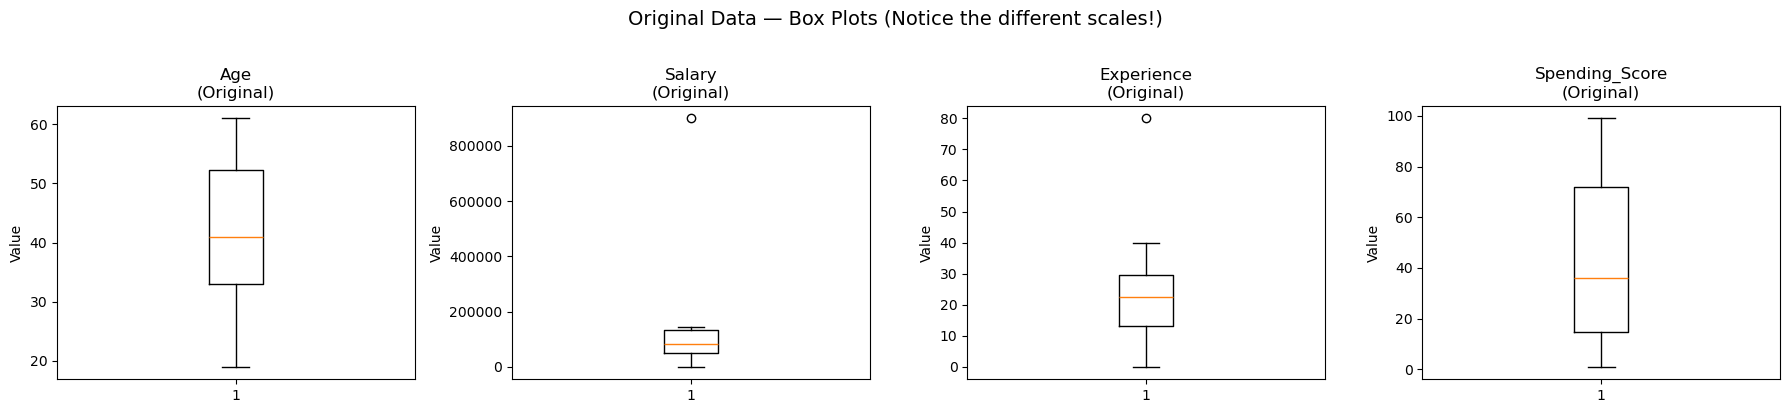

In [5]:
# ── Visualize original distributions ─────────────────────

# ── Create a figure with 1 row and 4 columns of subplots ──
# figsize=(18,4) means:
# width = 18 inches
# height = 4 inches
# fig = entire figure (container holding all plots)
# axes = array containing 4 plotting areas
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# ── Loop through each column in the DataFrame ──
# enumerate(df.columns) gives:
# i = position number (0,1,2,3)
# col = column name ('Age','Salary','Experience','Spending_Score')
for i, col in enumerate(df.columns):

     # Create boxplot for current column
    # df[col] = selects entire column
    # vert=True = draw boxplot vertically
    axes[i].boxplot(df[col], vert=True)
    
     # Set title for current subplot
    # f-string inserts column name dynamically
    # Example:
    # Age (Original)
    # Salary (Original)
    axes[i].set_title(f'{col}\n(Original)', fontsize=12)

    # Label y-axis
    # Indicates values shown on vertical axis
    axes[i].set_ylabel('Value')

# ── Add main title for entire figure ──
# fontsize=14 = title size
# y=1.02 moves title slightly upward
fig.suptitle("Original Data — Box Plots (Notice the different scales!)", fontsize=14, y=1.02)

# ── Automatically adjust spacing between plots ──
# Prevents titles and labels from overlapping
plt.tight_layout()
plt.show()# ── Display all plots on screen ──

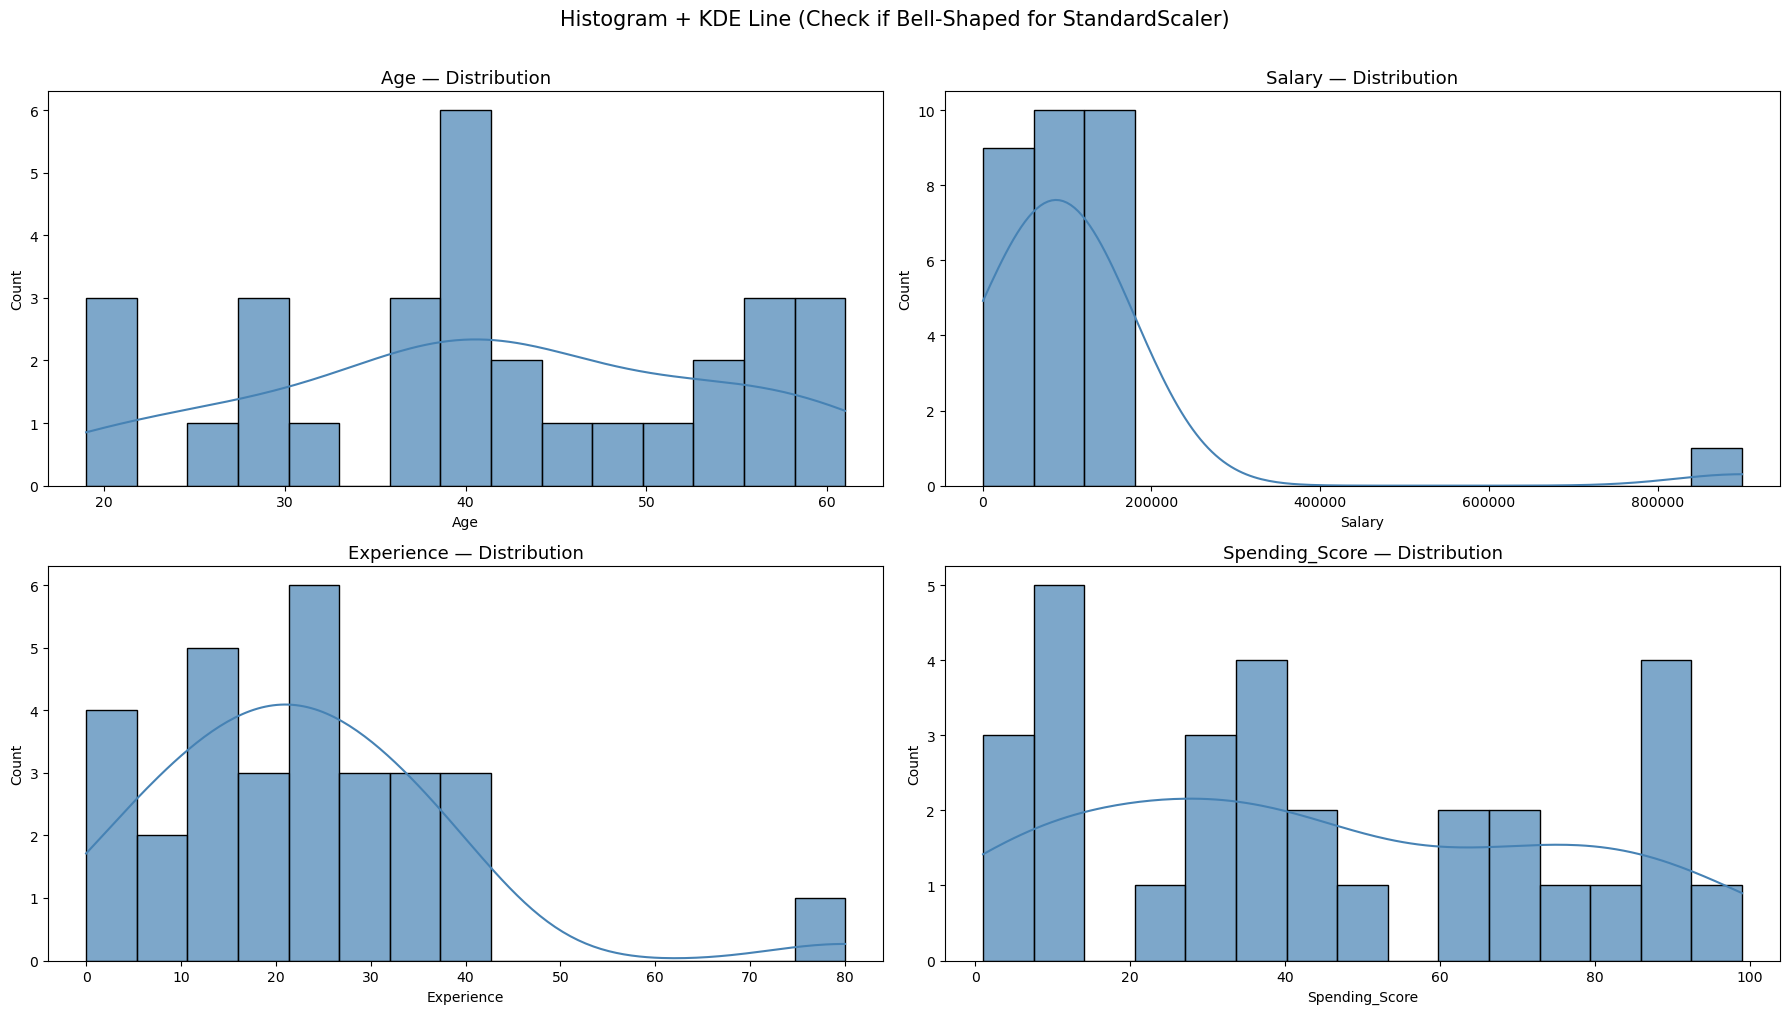

In [6]:
# Also see the distribution of the data using histograms

# If bell-shaped → use StandardScaler | If not → use MinMaxScaler or RobustScaler

# Create 4 histogram + KDE plots to visualize the distribution of all features.
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Convert 2D subplot array into a 1D array for easier indexing.
axes = axes.flatten() #flatten() simply turns a matrix of plots into a single list of plots, making loops much easier to write. 

# axes[0] → Age
sns.histplot(df['Age'], bins=15, kde=True, color='steelblue', edgecolor='black', alpha=0.7, ax=axes[0])
axes[0].set_title('Age — Distribution', fontsize=13)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# axes[1] → Salary
sns.histplot(df['Salary'], bins=15, kde=True, color='steelblue', edgecolor='black', alpha=0.7, ax=axes[1])
axes[1].set_title('Salary — Distribution', fontsize=13)
axes[1].set_xlabel('Salary')
axes[1].set_ylabel('Count')

# axes[2] → Experience
sns.histplot(df['Experience'], bins=15, kde=True, color='steelblue', edgecolor='black', alpha=0.7, ax=axes[2])
axes[2].set_title('Experience — Distribution', fontsize=13)
axes[2].set_xlabel('Experience')
axes[2].set_ylabel('Count')

# axes[3] → Spending_Score
sns.histplot(df['Spending_Score'], bins=15, kde=True, color='steelblue', edgecolor='black', alpha=0.7, ax=axes[3])
axes[3].set_title('Spending_Score — Distribution', fontsize=13)
axes[3].set_xlabel('Spending_Score')
axes[3].set_ylabel('Count')

fig.suptitle("Histogram + KDE Line (Check if Bell-Shaped for StandardScaler)", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [7]:
# Standardization (Z-Score Scaling)

# ══════════════════════════════════════════════════════════
#  1) STANDARDIZATION  (StandardScaler)
# ══════════════════════════════════════════════════════════

scaler_standard = StandardScaler()

# fit_transform learns mean & std, then transforms
df_standard = pd.DataFrame(
    scaler_standard.fit_transform(df),
    columns=df.columns
)

print("── After StandardScaler ──")
print(f"Means  : {df_standard.mean().round(6).values}")   # ≈ 0
print(f"Stds   : {df_standard.std().round(2).values}")     # ≈ 1
print()
df_standard.head(10)


── After StandardScaler ──
Means  : [-0. -0. -0. -0.]
Stds   : [1.02 1.02 1.02 1.02]



,Age,Salary,Experience,Spending_Score
0,1.177282,5.161316,0.798247,0.897520
1,0.372761,-0.733800,1.055745,-1.171113
2,-0.753568,0.216647,3.695109,1.464725
3,1.499091,-0.620767,-1.390494,-1.438033
4,-1.316733,0.172947,-1.132995,-1.204478
5,-0.270855,-0.208024,-1.261744,1.464725
6,1.177282,0.213095,0.347623,0.630599
7,-0.431760,-0.083968,-0.360498,-1.104383
8,-0.109951,0.143396,0.154499,1.231170
9,-1.075376,-0.196817,0.669497,-1.204478


In [8]:
# ── Manual verification of StandardScaler for 'Age' column ──
age_mean = df['Age'].mean()
age_std  = df['Age'].std(ddof=0)  # sklearn uses population std (ddof=0)

manual_z = (df['Age'] - age_mean) / age_std
sklearn_z = df_standard['Age']

print(f"Age Mean  = {age_mean:.2f}")
print(f"Age Std   = {age_std:.2f}")
print(f"\nManual Z-scores match sklearn? → {np.allclose(manual_z.values, sklearn_z.values)}")
print()

# Show side by side
pd.DataFrame({
    'Age_Original': df['Age'],
    'Manual_Z': manual_z.round(4),
    'Sklearn_Z': sklearn_z.round(4)
}).head(10)

Age Mean  = 41.37
Age Std   = 12.43

Manual Z-scores match sklearn? → True



,Age_Original,Manual_Z,Sklearn_Z
0,56,1.1773,1.1773
1,46,0.3728,0.3728
2,32,-0.7536,-0.7536
3,60,1.4991,1.4991
4,25,-1.3167,-1.3167
5,38,-0.2709,-0.2709
6,56,1.1773,1.1773
7,36,-0.4318,-0.4318
8,40,-0.1100,-0.1100
9,28,-1.0754,-1.0754


In [9]:
 # Normalization (Min-Max Scaling)

# ══════════════════════════════════════════════════════════
#  2) NORMALIZATION  (MinMaxScaler)
# ══════════════════════════════════════════════════════════

scaler_minmax = MinMaxScaler()

df_minmax = pd.DataFrame(
    scaler_minmax.fit_transform(df),
    columns=df.columns
)

print("── After MinMaxScaler ──")
print(f"Min values : {df_minmax.min().values}")   # all 0.0
print(f"Max values : {df_minmax.max().values}")    # all 1.0
print()
df_minmax.head(10)

── After MinMaxScaler ──
Min values : [0. 0. 0. 0.]
Max values : [1. 1. 1. 1.]



,Age,Salary,Experience,Spending_Score
0,0.880952,1.000000,0.4375,0.714286
1,0.642857,0.000000,0.4875,0.081633
2,0.309524,0.161226,1.0000,0.887755
3,0.976190,0.019174,0.0125,0.000000
4,0.142857,0.153813,0.0625,0.071429
5,0.452381,0.089188,0.0375,0.887755
6,0.880952,0.160624,0.3500,0.632653
7,0.404762,0.110232,0.2125,0.102041
8,0.500000,0.148800,0.3125,0.816327
9,0.214286,0.091089,0.4125,0.071429


In [10]:
# ── Manual verification of MinMaxScaler for 'Salary' column ──
sal_min = df['Salary'].min()
sal_max = df['Salary'].max()

manual_minmax = (df['Salary'] - sal_min) / (sal_max - sal_min)
sklearn_minmax = df_minmax['Salary']

print(f"Salary Min = {sal_min},  Salary Max = {sal_max}")
print(f"\nManual Min-Max matches sklearn? → {np.allclose(manual_minmax.values, sklearn_minmax.values)}")
print()

# ⚠️ See how outlier compresses all normal salaries near 0
print("⚠️  Outlier Effect on Salary (MinMax):")
print(f"   Original salary row 0 (outlier 900K) → scaled = {sklearn_minmax.iloc[0]:.4f}")
print(f"   Original salary row 3 (normal)       → scaled = {sklearn_minmax.iloc[3]:.4f}")
print(f"   Most normal salaries are squeezed near 0!")

Salary Min = 500,  Salary Max = 900000

Manual Min-Max matches sklearn? → True

⚠️  Outlier Effect on Salary (MinMax):
   Original salary row 0 (outlier 900K) → scaled = 1.0000
   Original salary row 3 (normal)       → scaled = 0.0192
   Most normal salaries are squeezed near 0!


In [11]:
 # Robust Scaling

# ══════════════════════════════════════════════════════════
#  3) ROBUST SCALING  (RobustScaler)
# ══════════════════════════════════════════════════════════

scaler_robust = RobustScaler()

df_robust = pd.DataFrame(
    scaler_robust.fit_transform(df),
    columns=df.columns
)

print("── After RobustScaler ──")
print(f"Medians (should be ≈ 0): {df_robust.median().round(4).values}")
print()
df_robust.head(10)

── After RobustScaler ──
Medians (should be ≈ 0): [0. 0. 0. 0.]



,Age,Salary,Experience,Spending_Score
0,0.779221,10.051218,0.769231,0.614035
1,0.259740,-1.023368,1.015385,-0.473684
2,-0.467532,0.762146,3.538462,0.912281
3,0.987013,-0.811024,-1.323077,-0.614035
4,-0.831169,0.680050,-1.076923,-0.491228
5,-0.155844,-0.035643,-1.200000,0.912281
6,0.779221,0.755473,0.338462,0.473684
7,-0.259740,0.197410,-0.338462,-0.438596
8,-0.051948,0.624535,0.153846,0.789474
9,-0.675325,-0.014590,0.646154,-0.491228


In [12]:
# ── Manual verification of RobustScaler for 'Salary' column ──
sal_median = df['Salary'].median()
sal_q1     = df['Salary'].quantile(0.25)
sal_q3     = df['Salary'].quantile(0.75)
sal_iqr    = sal_q3 - sal_q1

manual_robust = (df['Salary'] - sal_median) / sal_iqr
sklearn_robust = df_robust['Salary']

print(f"Salary Median = {sal_median}")
print(f"Salary Q1 = {sal_q1},  Q3 = {sal_q3},  IQR = {sal_iqr}")
print(f"\nManual Robust matches sklearn? → {np.allclose(manual_robust.values, sklearn_robust.values)}")
print()

# Compare how Salary outlier is treated
print("🔍 Outlier Handling Comparison for Salary row 0 (900,000):")
print(f"   StandardScaler → {df_standard['Salary'].iloc[0]:.4f}")
print(f"   MinMaxScaler   → {df_minmax['Salary'].iloc[0]:.4f}")
print(f"   RobustScaler   → {df_robust['Salary'].iloc[0]:.4f}")
print(f"\n   RobustScaler keeps the outlier as a large number but does NOT distort other values.")

Salary Median = 83620.0
Salary Q1 = 52341.5,  Q3 = 133563.5,  IQR = 81222.0

Manual Robust matches sklearn? → True

🔍 Outlier Handling Comparison for Salary row 0 (900,000):
   StandardScaler → 5.1613
   MinMaxScaler   → 1.0000
   RobustScaler   → 10.0512

   RobustScaler keeps the outlier as a large number but does NOT distort other values.


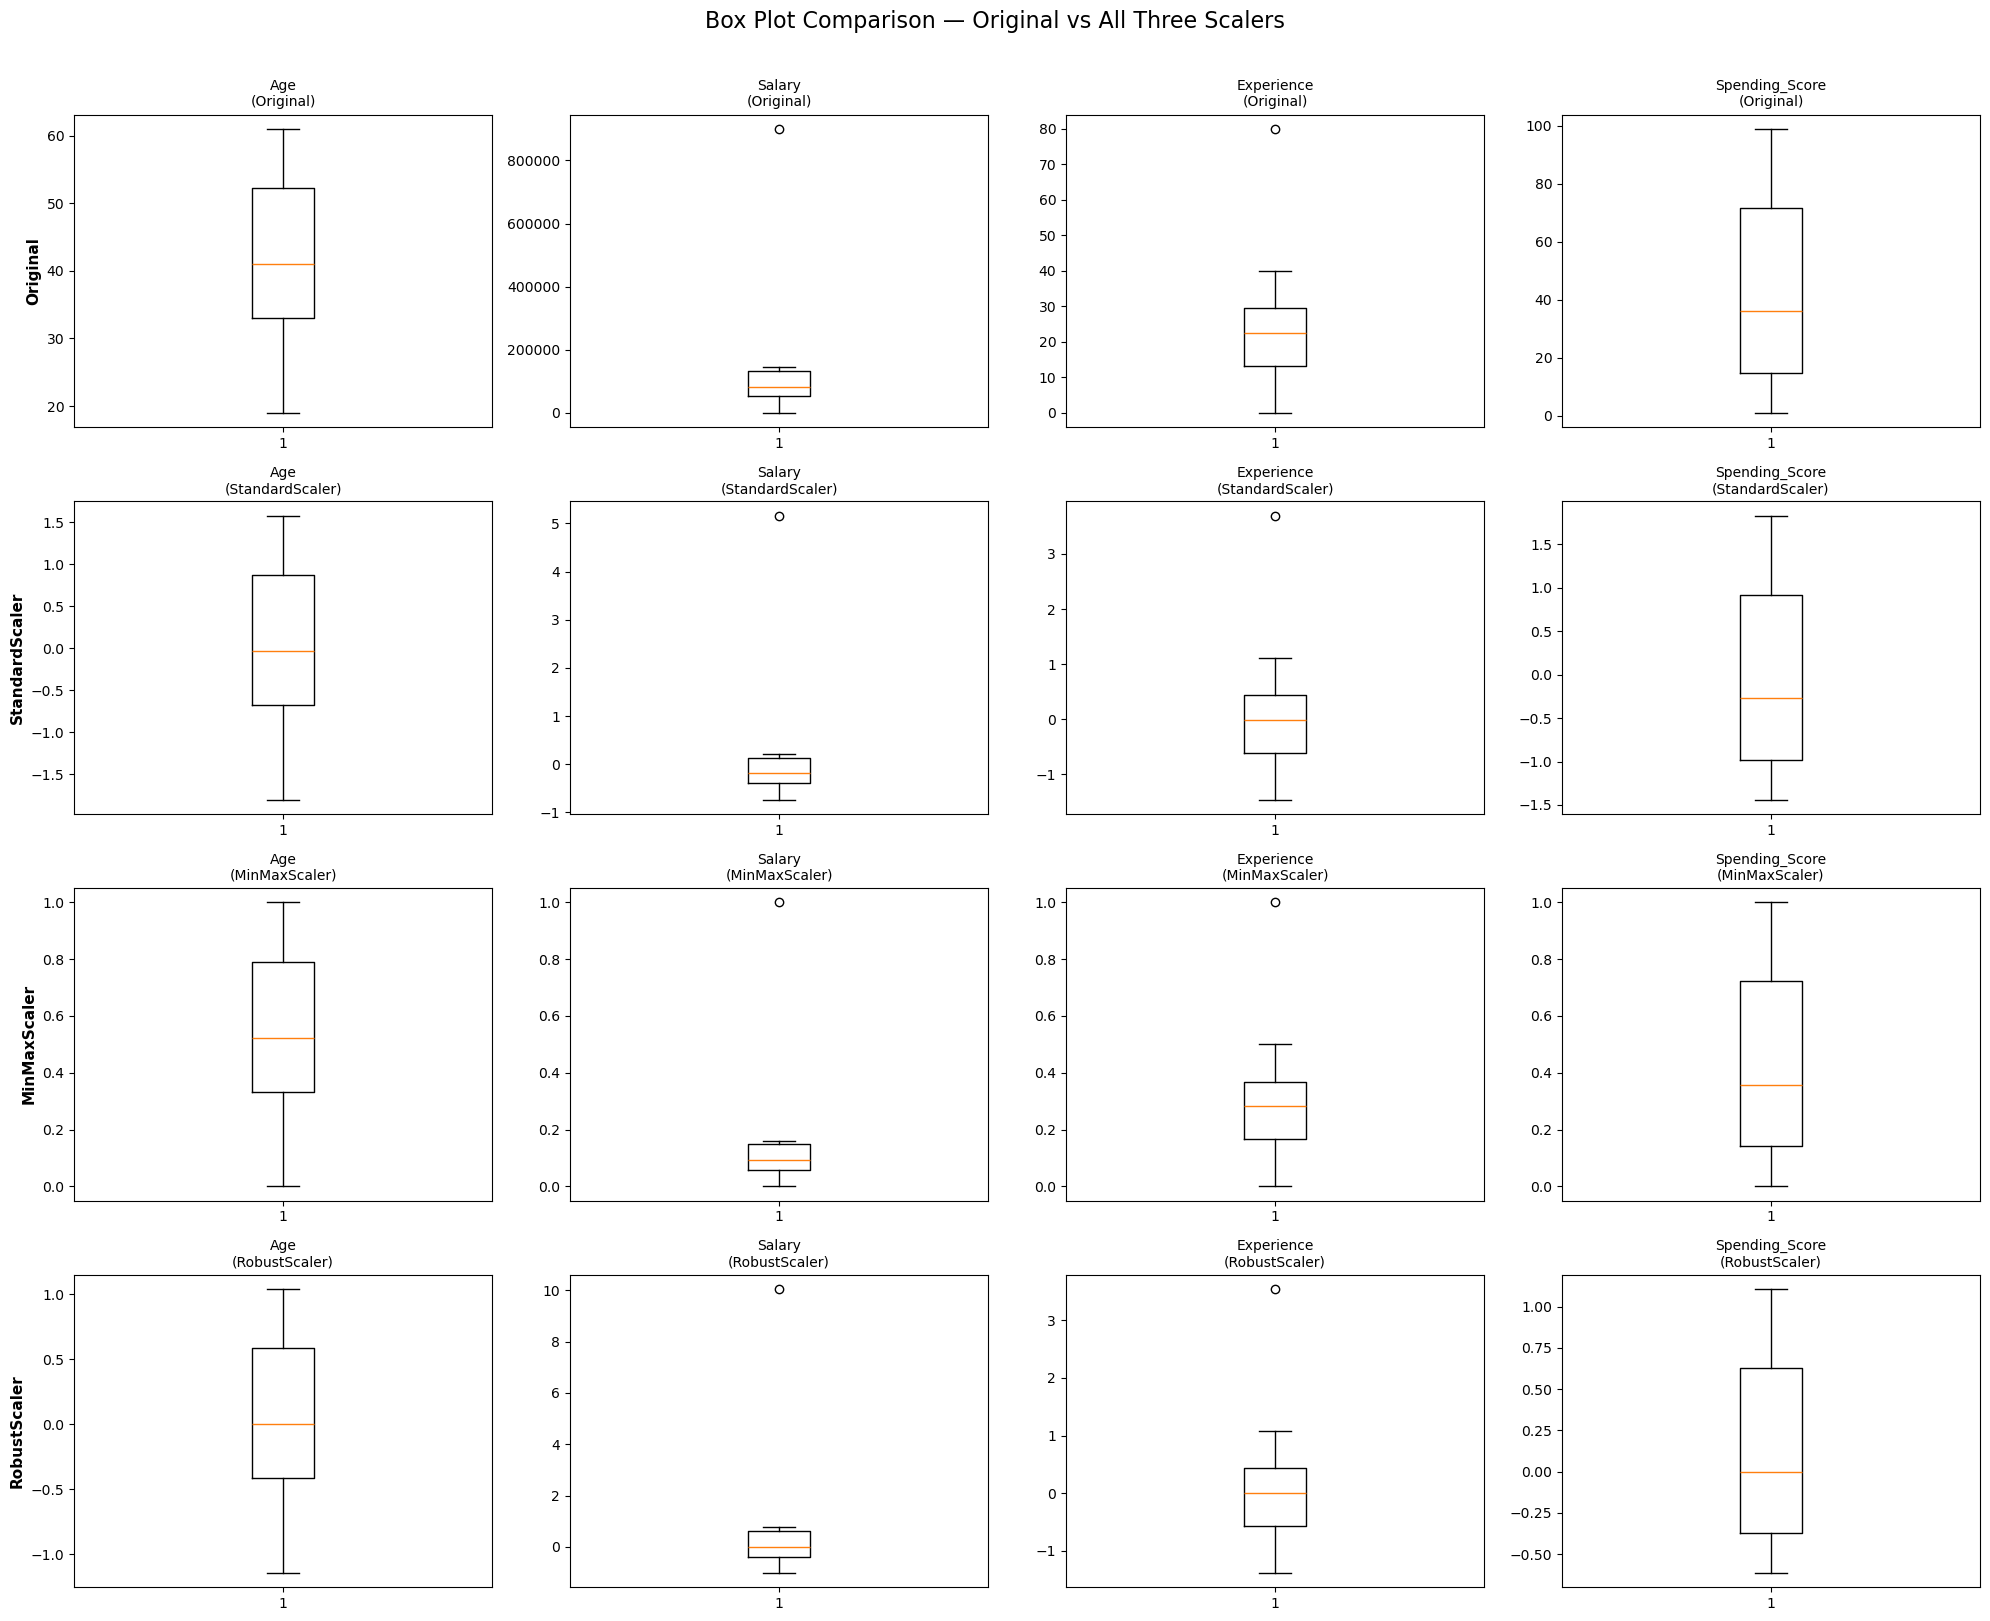

In [13]:
# ══════════════════════════════════════════════════════════
#  VISUAL COMPARISON — Box Plots for all 4 versions
# ══════════════════════════════════════════════════════════

datasets = {
    'Original':       df,
    'StandardScaler': df_standard,
    'MinMaxScaler':   df_minmax,
    'RobustScaler':   df_robust,
}

fig, axes = plt.subplots(4, 4, figsize=(20, 16))

for row, (name, data) in enumerate(datasets.items()):
    for col, feature in enumerate(df.columns):
        ax = axes[row][col]
        ax.boxplot(data[feature], vert=True)
        ax.set_title(f'{feature}\n({name})', fontsize=10)
        if col == 0:
            ax.set_ylabel(name, fontsize=11, fontweight='bold')

fig.suptitle("Box Plot Comparison — Original vs All Three Scalers", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [14]:
# ══════════════════════════════════════════════════════════
#  DEMO: Correct Train/Test Scaling Workflow
# ══════════════════════════════════════════════════════════
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test = train_test_split(df, test_size=0.3, random_state=42)

print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")
print()

# ── CORRECT approach ──
scaler = StandardScaler()

# Step 1: fit ONLY on training data
scaler.fit(X_train)

# Step 2: transform both using the SAME learned parameters
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=df.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=df.columns, index=X_test.index)

print("── Learned from TRAINING data ──")
print(f"  Mean (from fit): {scaler.mean_.round(2)}")
print(f"  Std  (from fit): {scaler.scale_.round(2)}")
print()
print("── Train set after scaling ──")
print(f"  Mean: {X_train_scaled.mean().round(4).values}")
print(f"  Std:  {X_train_scaled.std().round(4).values}")
print()
print("── Test set after scaling (mean ≠ exactly 0 because we used TRAIN params) ──")
print(f"  Mean: {X_test_scaled.mean().round(4).values}")
print(f"  Std:  {X_test_scaled.std().round(4).values}")

Train shape: (21, 4)
Test shape:  (9, 4)

── Learned from TRAINING data ──
  Mean (from fit): [4.2380000e+01 1.2144919e+05 2.4520000e+01 4.1520000e+01]
  Std  (from fit): [1.1690000e+01 1.8042414e+05 1.7070000e+01 3.0200000e+01]

── Train set after scaling ──
  Mean: [ 0.  0. -0. -0.]
  Std:  [1.0247 1.0247 1.0247 1.0247]

── Test set after scaling (mean ≠ exactly 0 because we used TRAIN params) ──
  Mean: [-0.2893 -0.166  -0.3757  0.2844]
  Std:  [1.245  0.1879 0.6077 1.0029]


In [15]:
# Inverse Transform 


# ══════════════════════════════════════════════════════════
#  INVERSE TRANSFORM — Get Original Values Back
# ══════════════════════════════════════════════════════════

# Let's inverse-transform the StandardScaler output
df_back_from_standard = pd.DataFrame(
    scaler_standard.inverse_transform(df_standard),
    columns=df.columns
)

print("── Original Data (first 5 rows) ──")
print(df.head().to_string())
print()
print("── After inverse_transform of StandardScaler (first 5 rows) ──")
print(df_back_from_standard.head().round(2).to_string())
print()
print(f"✅ Values match original? → {np.allclose(df.values, df_back_from_standard.values)}")

── Original Data (first 5 rows) ──
   Age  Salary  Experience  Spending_Score
0   56  900000          35              71
1   46     500          39               9
2   32  145523          80              88
3   60   17747           1               1
4   25  138855           5               8

── After inverse_transform of StandardScaler (first 5 rows) ──
    Age    Salary  Experience  Spending_Score
0  56.0  900000.0        35.0            71.0
1  46.0     500.0        39.0             9.0
2  32.0  145523.0        80.0            88.0
3  60.0   17747.0         1.0             1.0
4  25.0  138855.0         5.0             8.0

✅ Values match original? → True
